In [467]:
import matplotlib.pyplot as plt
import numpy as np
import qiskit_aer
import scipy.constants as constants
from qiskit import transpile
from qiskit.circuit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit_aer_encore.simulator import generate_aer_simulator
from qiskit_hamiltonian_simulation.time_independent.direct import (
    MomentumDomainEvolutionQuadratic,
    PositionDomainEvolutionQuadratic,
)
from qiskit_hamiltonian_simulation.time_independent.sample_based import (
    KineticEvolutionSampleBased,
    PotentialEvolutionSampleBased,
)
from qiskit_signals.helper_types import EncodingType
from qiskit_signals.quantum_axis import (
    AngularWavenumberAxis,
    MomentumAxis,
    PositionAxis,
)
from qiskit_signals.quantum_signal import GenericQuantumSignal, QuadraticQuantumSignal
from qiskit_signals.sample_based_signal import ArbitrarySignalForSampleBasedProtocol

In [468]:
num_qubits = 10
dimension = 2**num_qubits

In [469]:
wavelength = 550e-9
k_0 = 2 * constants.pi / wavelength
hbar = constants.hbar
c = constants.c

In [470]:
delta_x = 1 / dimension

In [471]:
# t = 100000 / c
t = 1000 / c
num_of_cycles = 100
delta_t = t / num_of_cycles

In [472]:
x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)
p_axis = MomentumAxis.from_position_axis(x_axis, hbar=hbar)
k_axis = AngularWavenumberAxis.from_position_axis(x_axis)

In [473]:
x_axis.axis_values

array([0.00000000e+00, 9.76562500e-04, 1.95312500e-03, ...,
       9.97070312e-01, 9.98046875e-01, 9.99023438e-01], shape=(1024,))

In [474]:
k_axis.axis_values

array([  0.        ,   6.28318531,  12.56637061, ..., -18.84955592,
       -12.56637061,  -6.28318531], shape=(1024,))

In [475]:
# def psi_signal_function(x):
#     sigma = 1 / 32
#     mu = 1 / 2
#     norm_factor = 1 / (sigma * (2 * constants.pi) ** 0.25)
#     return norm_factor * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def psi_signal_function(x):
    signal = np.zeros(dimension)
    middle = dimension // 2
    signal[middle - 20 : middle - 15] = 1
    signal[middle + 15 : middle + 20] = 1
    return signal


psi = GenericQuantumSignal(x_axis, psi_signal_function)

In [476]:
coef = -1 / 2 / k_0 * c * delta_t
quadratic_signal = QuadraticQuantumSignal(axis=k_axis, alpha=coef)
propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=quadratic_signal)

In [477]:
psi_reg = QuantumRegister(num_qubits, name=r"\psi")
# phi_reg = QuantumRegister(num_qubits, name=r"\phi")
# success_flag = ClassicalRegister(num_qubits, name="success_flag")
# circuit = QuantumCircuit(psi_reg, phi_reg, success_flag)
circuit = QuantumCircuit(psi_reg)

circuit.initialize(psi.data.tolist() / np.linalg.norm(psi.data), psi_reg)

circuit.save_statevector(label=f"step_{0}")  # type: ignore

for i in range(num_of_cycles):
    circuit.compose(
        propagator,
        psi_reg,
        inplace=True,
    )

    circuit.save_statevector(label=f"step_{i + 1}")  # type: ignore

# circuit.draw("mpl")

In [478]:
simulator = generate_aer_simulator()
transpiled_circuit = transpile(circuit, simulator)
job = simulator.run(transpiled_circuit, shots=1)
result = job.result()

In [479]:
def process_statevector(statevector):
    return statevector


statevectors = [
    process_statevector(result.data()[f"step_{i}"]) for i in range(num_of_cycles + 1)
]

In [480]:
def plot_wavefunction(psi, plot_size_scale=1, normalize=True):
    abs_part = np.abs(psi)
    if normalize:
        abs_part = abs_part / np.linalg.norm(abs_part)
    phase_part = np.angle(psi)

    num_of_basis = len(abs_part)
    num_of_qubits = (num_of_basis - 1).bit_length()
    x_axis = np.arange(num_of_basis)

    # ket_labels = [
    #     rf"$|{np.binary_repr(x, width=num_of_qubits)}\rangle$" for x in x_axis
    # ]
    # example:
    # KET_LABELS = [r'$|000\rangle$', r'$|001\rangle$', r'$|010\rangle$', r'$|011\rangle$', r'$|100\rangle$', r'$|101\rangle$', r'$|110\rangle$', r'$|111\rangle$']

    PHASE_LABELS = [
        r"$-\pi$",
        r"$-\frac{3\pi}{4}$",
        r"$-\frac{\pi}{2}$",
        r"$-\frac{\pi}{4}$",
        r"$0$",
        r"$\frac{\pi}{4}$",
        r"$\frac{\pi}{2}$",
        r"$\frac{3\pi}{4}$",
        r"$\pi$",
    ]

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(2 * 6.4 * plot_size_scale, 1 * 4.8 * plot_size_scale)
    )
    ax1.plot(abs_part)
    ax2.plot(phase_part)
    ax2.set_ylim(-np.pi - 0.3, np.pi + 0.3)

    # ax1.set_xticks(x_axis, ket_labels, rotation=45)
    # ax2.set_xticks(x_axis, ket_labels, rotation=45)

    ax2.set_yticks(
        [
            -np.pi,
            -np.pi * 3 / 4,
            -np.pi / 2,
            -np.pi / 4,
            0,
            np.pi / 4,
            np.pi / 2,
            np.pi * 3 / 4,
            np.pi,
        ]
    )
    ax2.set_yticklabels(PHASE_LABELS)

    ax1.set_xlabel(r"$|x\rangle$")
    ax2.set_xlabel(r"$|x\rangle$")

    ax1.set_ylabel(r"$|\psi(x)|$")
    ax2.set_ylabel(r"$\angle\psi(x)$")

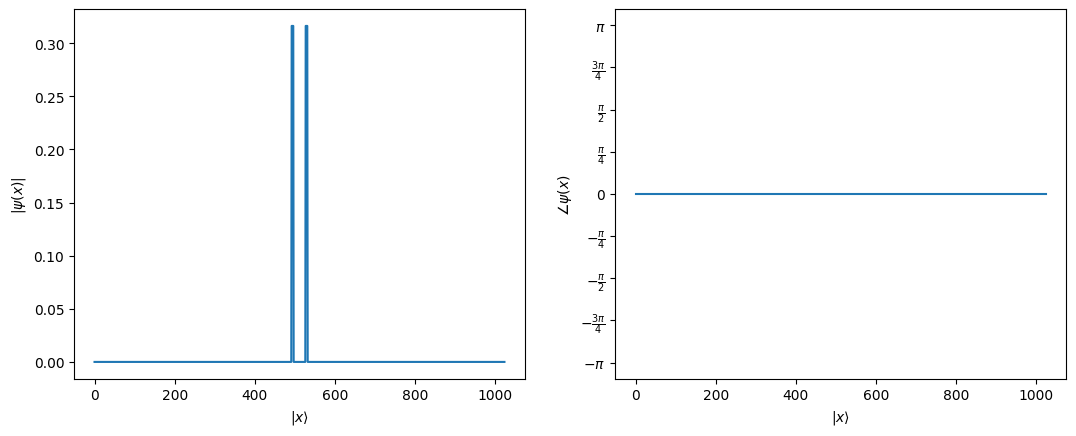

In [481]:
plot_wavefunction(statevectors[0])


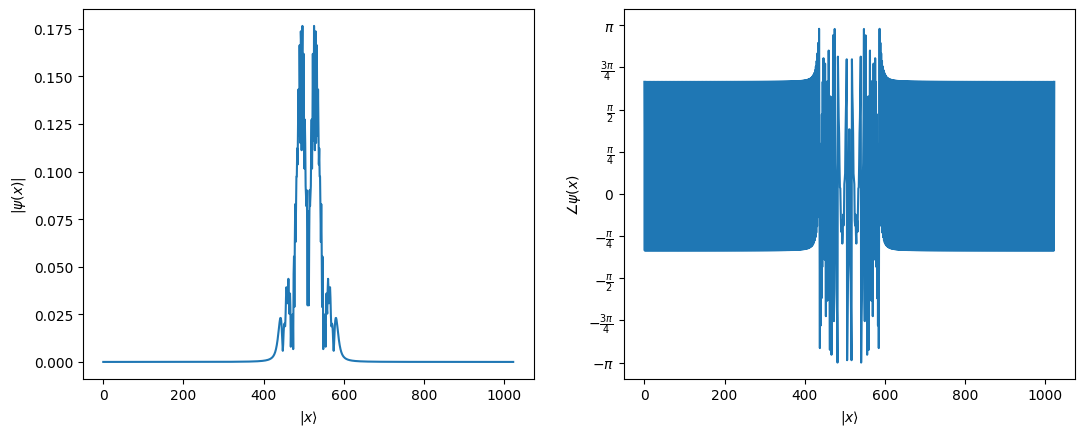

In [482]:
plot_wavefunction(statevectors[num_of_cycles // 5])


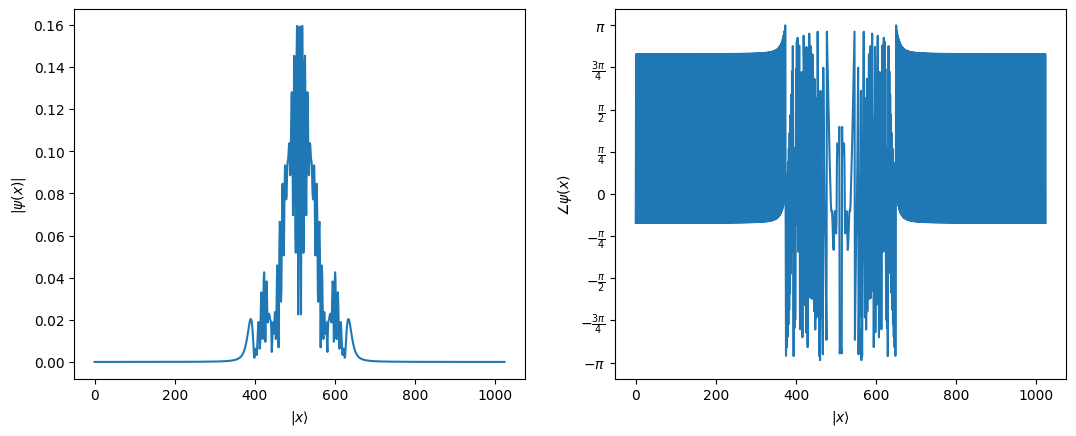

In [483]:
plot_wavefunction(statevectors[num_of_cycles // 5 * 2])

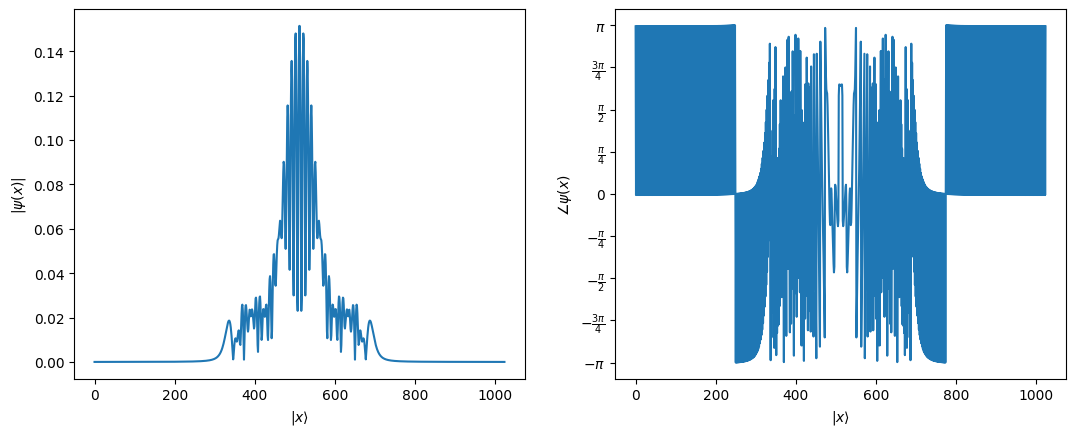

In [484]:
plot_wavefunction(statevectors[num_of_cycles // 5 * 3])


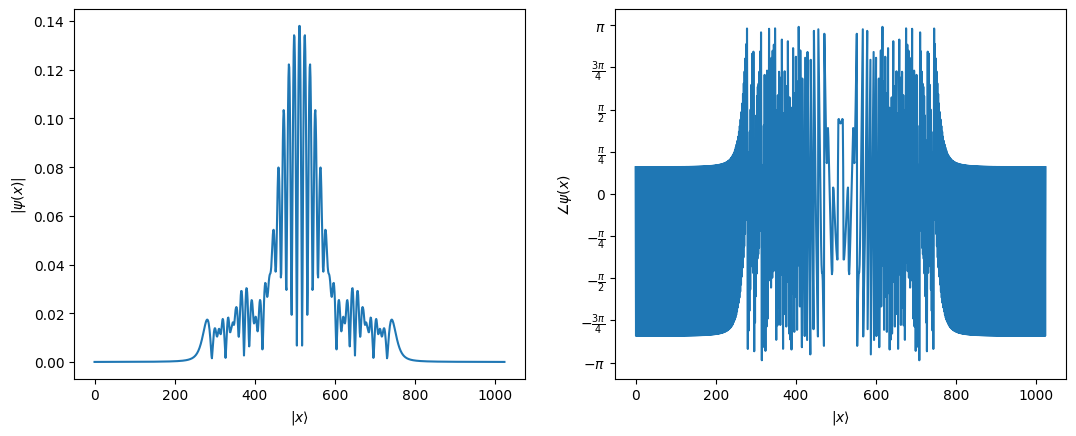

In [485]:
plot_wavefunction(statevectors[num_of_cycles // 5 * 4])


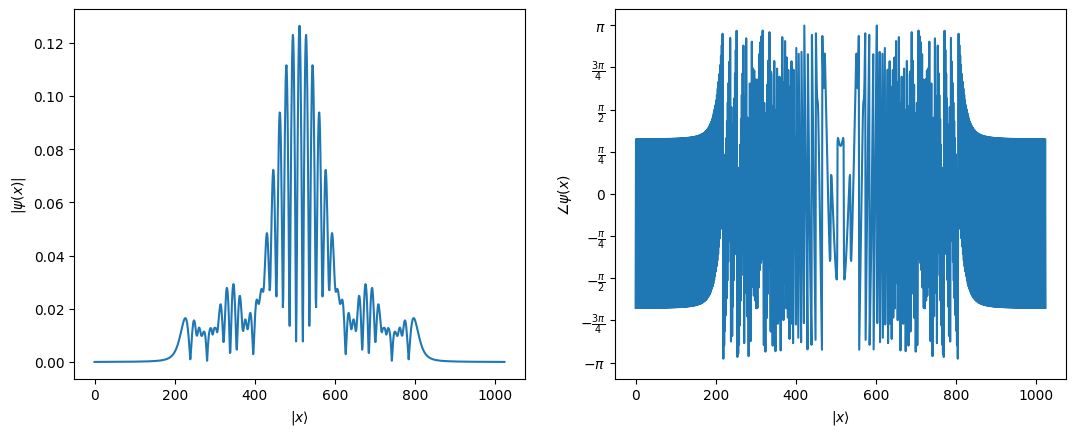

In [486]:
plot_wavefunction(statevectors[num_of_cycles])
